# Crime Analysis and Statistical Inference Report

**Week 2 Group Assignment — Crime & House Prices**  
Analysis of how crime type and volume relates to median house prices across London LSOAs (2022).  
All analyses are conducted across four dataset scenarios to account for spatial confounding.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

In [25]:
merged_df = pd.read_csv('data/final_dataset.csv')
print(f'Dataset loaded: {len(merged_df):,} LSOAs')
print(merged_df.columns.tolist())

Dataset loaded: 4,757 LSOAs
['Local authority code', 'Local authority name', 'LSOA code', 'LSOA name', 'Median House Price 2022', 'Arson and Criminal Damage', 'Burglary', 'Drug Offences', 'Miscellaneous Crimes Against Society', 'Possession of Weapons', 'Public Order Offences', 'Robbery', 'Theft', 'Vehicle Offences', 'Violence Against The Person', 'Total Crime 2022', 'IMD Score', 'Income Deprivation Rank', 'Employment Deprivation Rank', 'Education Deprivation Rank', 'Health Deprivation Rank', 'Crime Deprivation Rank', 'Housing and Services Deprivation Rank', 'Living Environment Deprivation Rank', 'Total Population 2015', 'Average PTAI 2015', 'PTAL']


In [26]:
# Define the four analysis scenarios used throughout Tasks 1–4
CRIME_COLS = [
    'Arson and Criminal Damage', 'Burglary', 'Drug Offences',
    'Miscellaneous Crimes Against Society', 'Possession of Weapons',
    'Public Order Offences', 'Robbery', 'Theft',
    'Vehicle Offences', 'Violence Against The Person'
]

q95_price = merged_df['Median House Price 2022'].quantile(0.95)
q95_crime = merged_df['Total Crime 2022'].quantile(0.95)

scenarios = {
    'All London': merged_df.copy(),
    'Excl. Westminster': merged_df[~merged_df['LSOA name'].str.contains('Westminster', case=False)].copy(),
    'Excl. Westminster & K&C': merged_df[
        ~merged_df['LSOA name'].str.contains('Westminster|Kensington and Chelsea', case=False)
    ].copy(),
    'Trim Top 5% (Crime & Price)': merged_df[
        (merged_df['Median House Price 2022'] <= q95_price) &
        (merged_df['Total Crime 2022'] <= q95_crime)
    ].copy()
}

for name, df in scenarios.items():
    print(f'{name}: N = {len(df):,}')

All London: N = 4,757
Excl. Westminster: N = 4,633
Excl. Westminster & K&C: N = 4,535
Trim Top 5% (Crime & Price): N = 4,302


---
## Task 1: Explanatory Data Analysis (Crime & House Prices)

We build on Week 1's EDA with both **Univariate** and **Bivariate** analyses, and identify the spatial confounding effect that makes Westminster a special case.

### 1. Univariate Analysis: Descriptive Statistics

Key summary statistics for our target variable (`Median House Price 2022`) and the primary predictor (`Total Crime 2022`).

In [27]:
# Summary statistics
print('=== MEDIAN HOUSE PRICE 2022 ===')
print(merged_df['Median House Price 2022'].describe().apply(lambda x: f'£{x:,.0f}'))

print('\n=== TOTAL CRIME 2022 ===')
print(merged_df['Total Crime 2022'].describe().apply(lambda x: f'{x:,.1f}'))

price_med = merged_df['Median House Price 2022'].median()
crime_med = merged_df['Total Crime 2022'].median()
crime_q25 = merged_df['Total Crime 2022'].quantile(0.25)
crime_q75 = merged_df['Total Crime 2022'].quantile(0.75)
print(f'\nHouse Price Median: £{price_med:,.0f}')
print(f'Crime Median: {crime_med:.0f}, IQR: [{crime_q25:.0f}, {crime_q75:.0f}]')

=== MEDIAN HOUSE PRICE 2022 ===
count        £4,757
mean       £617,913
std        £396,309
min        £147,500
25%        £420,000
50%        £520,000
75%        £683,000
max      £6,425,000
Name: Median House Price 2022, dtype: str

=== TOTAL CRIME 2022 ===
count    4,757.0
mean       167.8
std        300.9
min          2.0
25%         79.0
50%        115.0
75%        174.0
max      9,206.0
Name: Total Crime 2022, dtype: str

House Price Median: £520,000
Crime Median: 115, IQR: [79, 174]


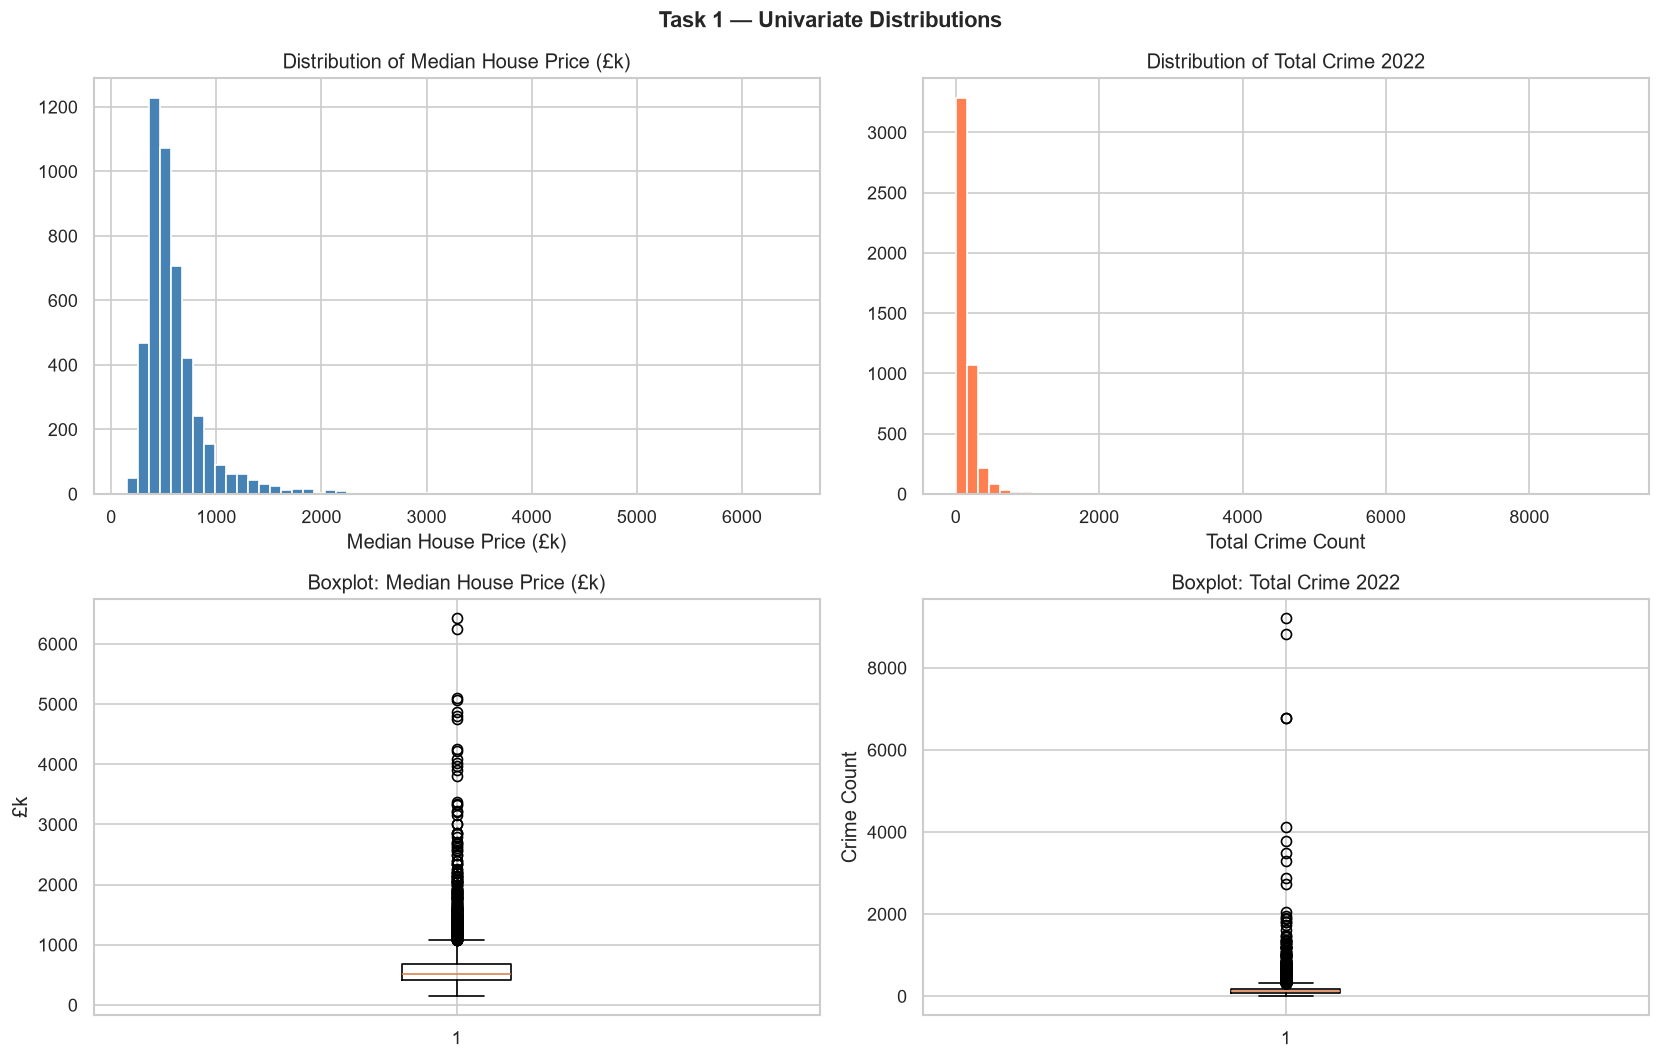

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histograms
axes[0, 0].hist(merged_df['Median House Price 2022'] / 1e3, bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Median House Price (£k)')
axes[0, 0].set_xlabel('Median House Price (£k)')

axes[0, 1].hist(merged_df['Total Crime 2022'], bins=60, color='coral', edgecolor='white')
axes[0, 1].set_title('Distribution of Total Crime 2022')
axes[0, 1].set_xlabel('Total Crime Count')

# Boxplots
axes[1, 0].boxplot(merged_df['Median House Price 2022'] / 1e3, vert=True)
axes[1, 0].set_title('Boxplot: Median House Price (£k)')
axes[1, 0].set_ylabel('£k')

axes[1, 1].boxplot(merged_df['Total Crime 2022'], vert=True)
axes[1, 1].set_title('Boxplot: Total Crime 2022')
axes[1, 1].set_ylabel('Crime Count')

plt.suptitle('Task 1 — Univariate Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2. Bivariate Analysis: Total Crime vs Median House Price

We plot the relationship across all LSOAs and across each of the four scenarios to illustrate how spatial confounding affects the apparent direction of the correlation.

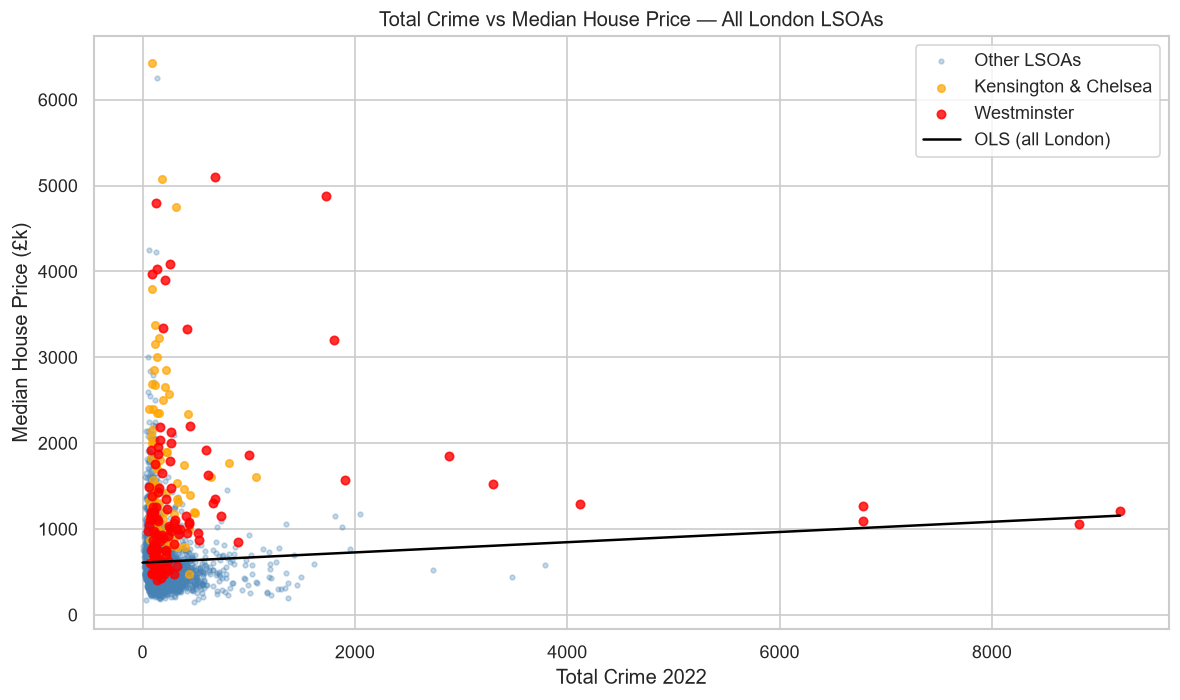

In [29]:
# Highlight Westminster vs rest
is_west = merged_df['LSOA name'].str.contains('Westminster', case=False)
is_kc   = merged_df['LSOA name'].str.contains('Kensington and Chelsea', case=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(merged_df.loc[~is_west & ~is_kc, 'Total Crime 2022'],
           merged_df.loc[~is_west & ~is_kc, 'Median House Price 2022'] / 1e3,
           alpha=0.3, s=8, color='steelblue', label='Other LSOAs')
ax.scatter(merged_df.loc[is_kc, 'Total Crime 2022'],
           merged_df.loc[is_kc, 'Median House Price 2022'] / 1e3,
           alpha=0.7, s=20, color='orange', label='Kensington & Chelsea')
ax.scatter(merged_df.loc[is_west, 'Total Crime 2022'],
           merged_df.loc[is_west, 'Median House Price 2022'] / 1e3,
           alpha=0.8, s=25, color='red', label='Westminster')

# OLS line (all data)
X_all = sm.add_constant(merged_df['Total Crime 2022'])
fit_all = sm.OLS(merged_df['Median House Price 2022'], X_all).fit()
x_range = np.linspace(0, merged_df['Total Crime 2022'].max(), 200)
y_hat = fit_all.params['const'] + fit_all.params['Total Crime 2022'] * x_range
ax.plot(x_range, y_hat / 1e3, color='black', linewidth=1.5, label='OLS (all London)')

ax.set_xlabel('Total Crime 2022')
ax.set_ylabel('Median House Price (£k)')
ax.set_title('Total Crime vs Median House Price — All London LSOAs')
ax.legend()
plt.tight_layout()
plt.show()

### 3. Outlier Profile: Identifying the Westminster Confound

To verify which specific areas are the high-leverage outliers, we list the top 10 LSOAs by Total Crime and by Median House Price.

In [30]:
display_cols = ['LSOA code', 'LSOA name', 'Local authority name',
                'Total Crime 2022', 'Median House Price 2022']

print('=== TOP 10 LSOAs BY TOTAL CRIME 2022 ===')
top_crime = merged_df.sort_values('Total Crime 2022', ascending=False).head(10)[display_cols]
top_crime['Median House Price 2022'] = top_crime['Median House Price 2022'].apply(lambda x: f'£{x:,.0f}')
print(top_crime.to_string(index=False))

print('\n=== TOP 10 LSOAs BY MEDIAN HOUSE PRICE 2022 ===')
top_price = merged_df.sort_values('Median House Price 2022', ascending=False).head(10)[display_cols]
top_price['Median House Price 2022'] = top_price['Median House Price 2022'].apply(lambda x: f'£{x:,.0f}')
print(top_price.to_string(index=False))

=== TOP 10 LSOAs BY TOTAL CRIME 2022 ===
LSOA code                 LSOA name Local authority name  Total Crime 2022 Median House Price 2022
E01004734          Westminster 018A          Westminster            9206.0              £1,212,500
E01004763          Westminster 013B          Westminster            8822.0              £1,052,500
E01033596          Westminster 013F          Westminster            6784.0              £1,097,150
E01033595          Westminster 013E          Westminster            6784.0              £1,270,000
E01004736          Westminster 018C          Westminster            4119.0              £1,290,000
E01033583               Newham 013G               Newham            3792.0                £584,000
E01002444           Hillingdon 031A           Hillingdon            3484.0                £435,500
E01004735          Westminster 018B          Westminster            3301.0              £1,525,000
E01004714          Westminster 011B          Westminster            

### 4. Segment Analysis: Correlation & OLS Slope Across Scenarios

We progressively remove the high-leverage outliers and re-compute Pearson r and the OLS slope to reveal the true direction of the relationship in typical residential areas.

In [31]:
print(f'{'Scenario':<42} {'N':>5} {'r':>8} {'p':>12} {'OLS Slope':>12}')
print('-' * 82)
for name, df in scenarios.items():
    r, p = pearsonr(df['Total Crime 2022'], df['Median House Price 2022'])
    X = sm.add_constant(df['Total Crime 2022'])
    slope = sm.OLS(df['Median House Price 2022'], X).fit().params['Total Crime 2022']
    print(f'{name:<42} {len(df):>5} {r:>8.4f} {p:>12.4e} {slope:>12.2f}')


Scenario                                       N        r            p    OLS Slope
----------------------------------------------------------------------------------
All London                                  4757   0.0451   1.8493e-03        59.43
Excl. Westminster                           4633  -0.0721   8.9373e-07      -146.23
Excl. Westminster & K&C                     4535  -0.1041   2.0968e-12      -173.34
Trim Top 5% (Crime & Price)                 4302  -0.2012   1.5619e-40      -517.90


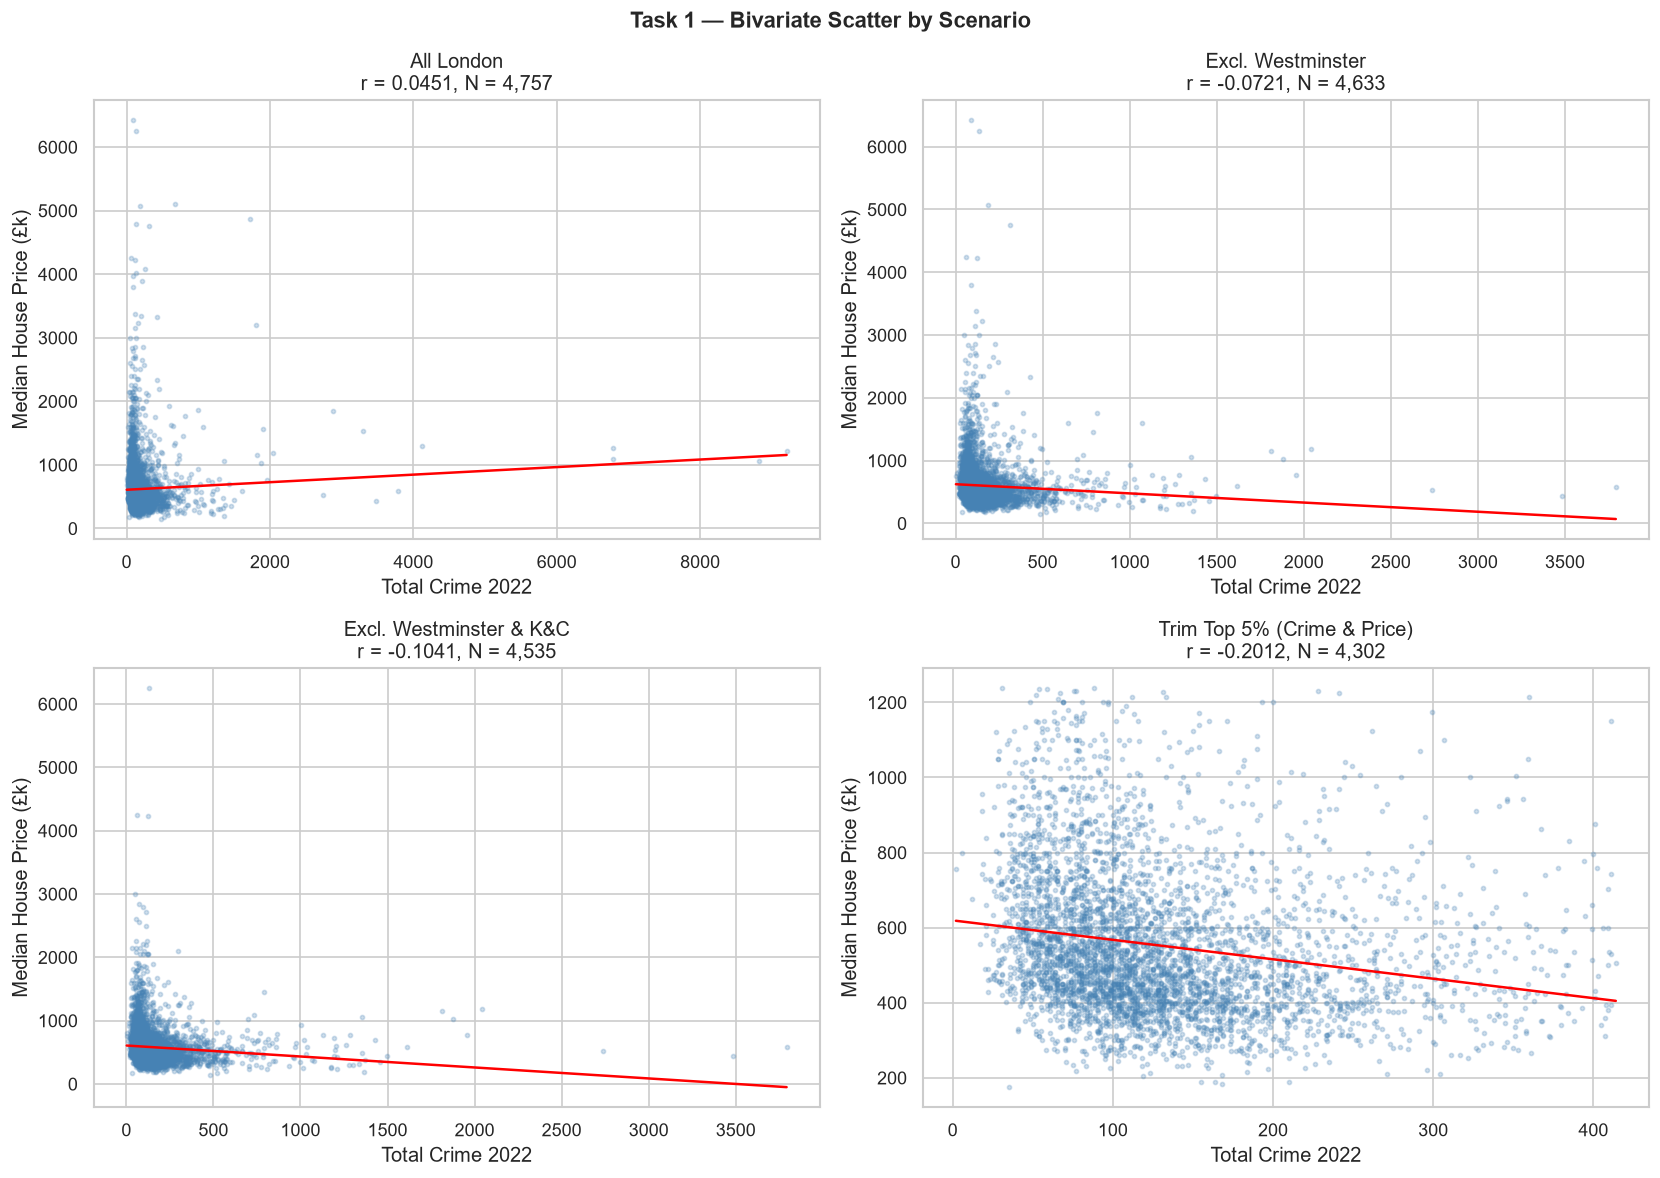

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (name, df) in zip(axes, scenarios.items()):
    ax.scatter(df['Total Crime 2022'], df['Median House Price 2022'] / 1e3,
               alpha=0.25, s=6, color='steelblue')
    X = sm.add_constant(df['Total Crime 2022'])
    fit = sm.OLS(df['Median House Price 2022'], X).fit()
    r, p = pearsonr(df['Total Crime 2022'], df['Median House Price 2022'])
    x_r = np.linspace(df['Total Crime 2022'].min(), df['Total Crime 2022'].max(), 200)
    ax.plot(x_r, (fit.params['const'] + fit.params['Total Crime 2022'] * x_r) / 1e3,
            color='red', linewidth=1.5)
    ax.set_title(f'{name}\nr = {r:.4f}, N = {len(df):,}')
    ax.set_xlabel('Total Crime 2022')
    ax.set_ylabel('Median House Price (£k)')
plt.suptitle('Task 1 — Bivariate Scatter by Scenario', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 2: Hypothesis Testing and Statistical Inference

We test two hypotheses identified from our EDA:
- **H1:** High-crime neighbourhoods have significantly lower median house prices than low-crime ones.
- **H2:** Individual crime categories have statistically significant effects on median house prices (regression coefficient ≠ 0).

Both hypotheses are tested across all four dataset scenarios.

### Hypothesis 1: One-Tailed Two-Sample Welch's t-Test

**H₀:** μ_high ≥ μ_low (high-crime areas have equal or higher prices)  
**H₁:** μ_high < μ_low (high-crime areas have lower prices)  

Groups are defined within each scenario using the 75th (high) and 25th (low) percentile thresholds of Total Crime.

In [33]:
h1_results = []
for name, df in scenarios.items():
    q75 = df['Total Crime 2022'].quantile(0.75)
    q25 = df['Total Crime 2022'].quantile(0.25)
    high = df[df['Total Crime 2022'] >= q75]['Median House Price 2022']
    low  = df[df['Total Crime 2022'] <= q25]['Median House Price 2022']
    t_stat, p_two = ttest_ind(high, low, equal_var=False)
    p_one = p_two / 2 if t_stat < 0 else 1 - p_two / 2
    diff = high.mean() - low.mean()
    se = np.sqrt(high.var(ddof=1)/len(high) + low.var(ddof=1)/len(low))
    ci_lo, ci_hi = diff - 1.96*se, diff + 1.96*se
    h1_results.append({'Scenario': name, 'N_high': len(high), 'N_low': len(low),
                        'Mean_High': high.mean(), 'Mean_Low': low.mean(),
                        'Diff': diff, 't_stat': t_stat, 'p_one': p_one,
                        'CI_lo': ci_lo, 'CI_hi': ci_hi})

h1_df = pd.DataFrame(h1_results)
print('=== H1: One-Tailed t-Test Results ===')
for _, row in h1_df.iterrows():
    sig = '*** REJECT H0' if row['p_one'] < 0.05 else 'Fail to reject H0'
    print(f"\nScenario: {row['Scenario']}")
    print(f"  Mean Price (High Crime): £{row['Mean_High']:,.2f}")
    print(f"  Mean Price (Low Crime):  £{row['Mean_Low']:,.2f}")
    print(f"  Difference: £{row['Diff']:,.2f}")
    print(f"  t = {row['t_stat']:.4f}, one-tailed p = {row['p_one']:.4e}")
    print(f"  95% CI: [£{row['CI_lo']:,.2f}, £{row['CI_hi']:,.2f}]")
    print(f"  Decision: {sig}")

=== H1: One-Tailed t-Test Results ===

Scenario: All London
  Mean Price (High Crime): £585,119.77
  Mean Price (Low Crime):  £694,646.13
  Difference: £-109,526.36
  t = -6.8626, one-tailed p = 4.3510e-12
  95% CI: [£-140,807.62, £-78,245.09]
  Decision: *** REJECT H0

Scenario: Excl. Westminster
  Mean Price (High Crime): £538,402.22
  Mean Price (Low Crime):  £690,899.37
  Difference: £-152,497.16
  t = -11.1711, one-tailed p = 1.4567e-28
  95% CI: [£-179,253.14, £-125,741.17]
  Decision: *** REJECT H0

Scenario: Excl. Westminster & K&C
  Mean Price (High Crime): £504,046.78
  Mean Price (Low Crime):  £687,167.98
  Difference: £-183,121.20
  t = -16.1788, one-tailed p = 1.4220e-55
  95% CI: [£-205,305.61, £-160,936.80]
  Decision: *** REJECT H0

Scenario: Trim Top 5% (Crime & Price)
  Mean Price (High Crime): £503,188.43
  Mean Price (Low Crime):  £630,002.87
  Difference: £-126,814.44
  t = -15.5594, one-tailed p = 3.9608e-52
  95% CI: [£-142,789.11, £-110,839.77]
  Decision: *** R

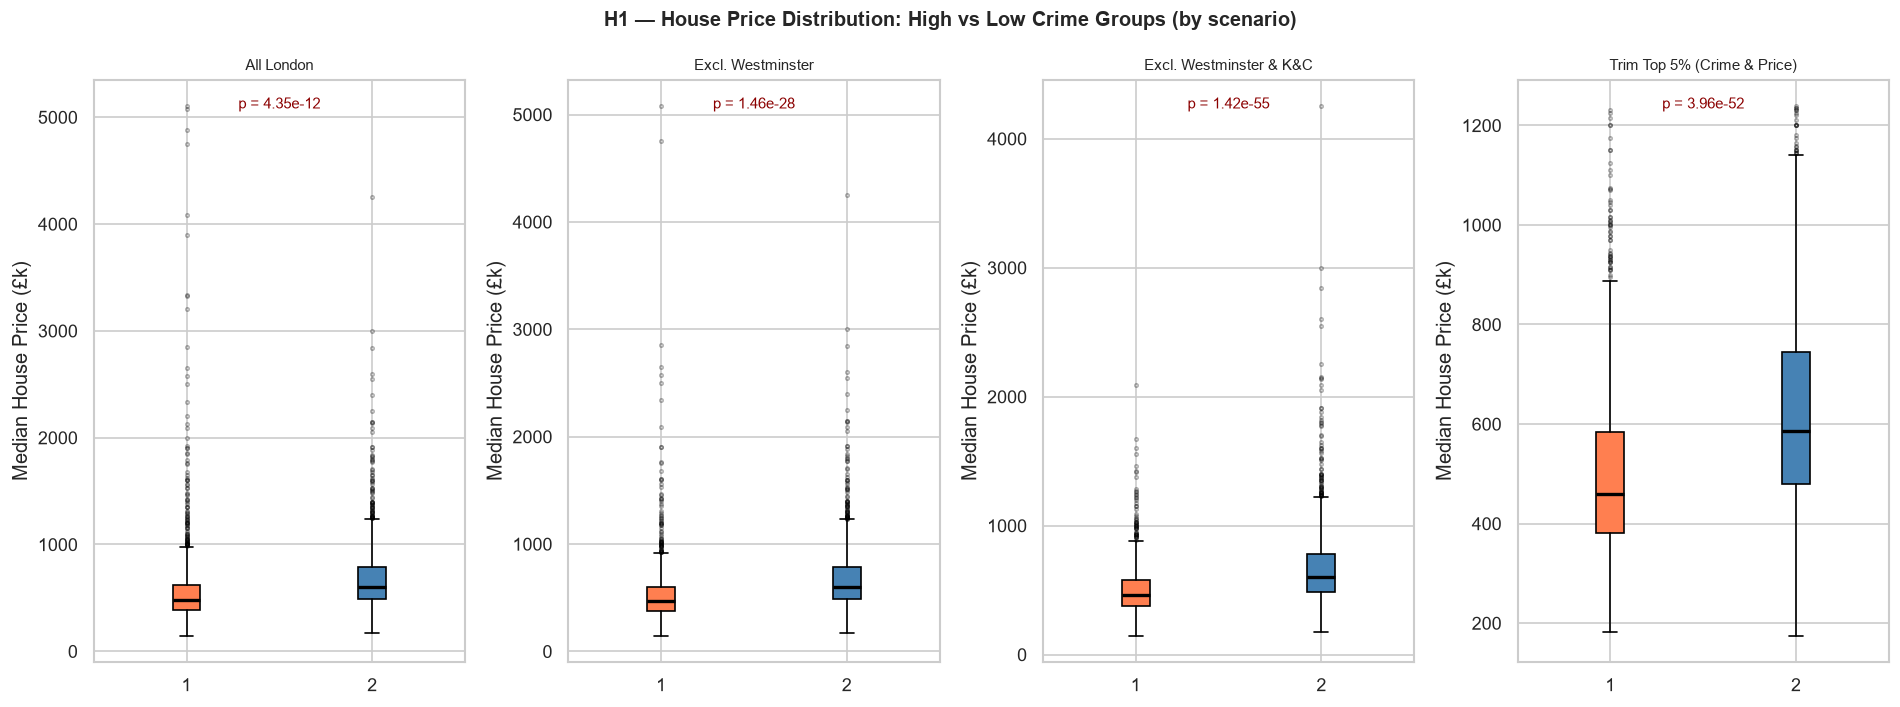

In [34]:
# Boxplots: distribution of house prices for High vs Low crime groups per scenario
fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=False)

for ax, (name, df) in zip(axes, scenarios.items()):
    q75 = df['Total Crime 2022'].quantile(0.75)
    q25 = df['Total Crime 2022'].quantile(0.25)
    high_prices = df[df['Total Crime 2022'] >= q75]['Median House Price 2022'] / 1e3
    low_prices  = df[df['Total Crime 2022'] <= q25]['Median House Price 2022'] / 1e3

    bp = ax.boxplot(
        [high_prices, low_prices],
        label=['High Crime', 'Low Crime'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor('coral')
    bp['boxes'][1].set_facecolor('steelblue')

    # Annotate with p-value from h1_results
    row = next(r for r in h1_results if r['Scenario'] == name)
    p_str = f"p = {row['p_one']:.2e}"
    ax.text(0.5, 0.97, p_str, transform=ax.transAxes, ha='center', va='top', fontsize=9,
            color='darkred' if row['p_one'] < 0.05 else 'black')

    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Median House Price (£k)')

plt.suptitle('H1 — House Price Distribution: High vs Low Crime Groups (by scenario)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Hypothesis 2: Significance of Crime Category Regression Coefficients

We fit a **multiple log-log OLS regression** for each scenario and test whether each of the 10 crime categories has a statistically significant coefficient (β ≠ 0).

**H₀:** βᵢ = 0 (crime type i has no effect on log house price)  
**H₁:** βᵢ ≠ 0 (crime type i has a significant effect)  
Significance level: α = 0.05.

In [35]:
h2_results = {}  # scenario -> statsmodels Results

for name, df in scenarios.items():
    X = np.log1p(df[CRIME_COLS])
    X = sm.add_constant(X)
    y = np.log(df['Median House Price 2022'])
    h2_results[name] = sm.OLS(y, X).fit()

print('=== H2: Coefficient Significance (all 10 crime types) ===')
for name, result in h2_results.items():
    print(f"\n--- Scenario: {name} (N={result.nobs:.0f}, R²={result.rsquared:.4f}) ---")
    coef_df = pd.DataFrame({
        'β': result.params[CRIME_COLS],
        't': result.tvalues[CRIME_COLS],
        'p-value': result.pvalues[CRIME_COLS],
        'CI lower': result.conf_int().loc[CRIME_COLS, 0],
        'CI upper': result.conf_int().loc[CRIME_COLS, 1]
    })
    coef_df['Significant (α=0.05)'] = coef_df['p-value'] < 0.05
    print(coef_df.round(4).to_string())

=== H2: Coefficient Significance (all 10 crime types) ===

--- Scenario: All London (N=4757, R²=0.2838) ---
                                           β        t  p-value  CI lower  CI upper  Significant (α=0.05)
Arson and Criminal Damage            -0.0745  -6.0458   0.0000   -0.0986   -0.0503                  True
Burglary                              0.0977   9.3918   0.0000    0.0773    0.1181                  True
Drug Offences                        -0.0642  -7.1530   0.0000   -0.0818   -0.0466                  True
Miscellaneous Crimes Against Society -0.0568  -5.9501   0.0000   -0.0756   -0.0381                  True
Possession of Weapons                -0.0192  -1.7875   0.0739   -0.0402    0.0019                 False
Public Order Offences                 0.0283   2.4275   0.0152    0.0054    0.0512                  True
Robbery                               0.0164   1.8483   0.0646   -0.0010    0.0338                 False
Theft                                 0.1555  16.905

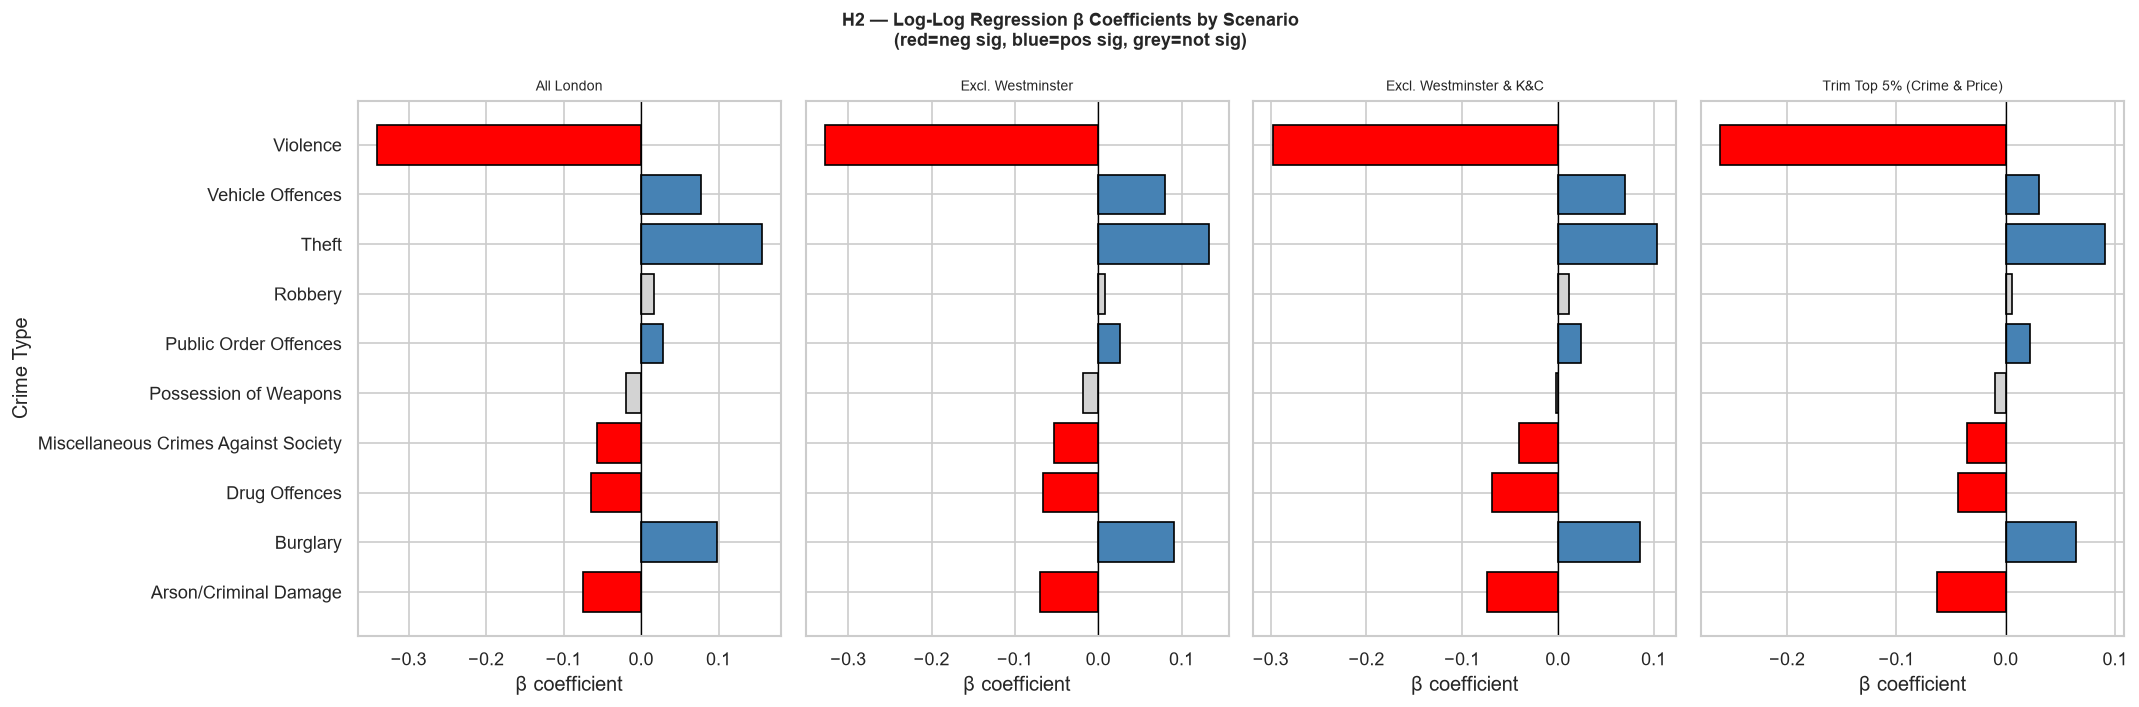

In [36]:
# Horizontal bar chart of β coefficients for each scenario
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
short_labels = [c.replace(' Against The Person', '').replace(' and ', '/') for c in CRIME_COLS]
for ax, (name, result) in zip(axes, h2_results.items()):
    coefs = result.params[CRIME_COLS].values
    pvals = result.pvalues[CRIME_COLS].values
    colors = ['red' if (c < 0 and p < 0.05) else 'steelblue' if (c > 0 and p < 0.05) else 'lightgrey'
              for c, p in zip(coefs, pvals)]
    ax.barh(short_labels, coefs, color=colors, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(name, fontsize=8.5)
    ax.set_xlabel('β coefficient')
axes[0].set_ylabel('Crime Type')
plt.suptitle('H2 — Log-Log Regression β Coefficients by Scenario\n(red=neg sig, blue=pos sig, grey=not sig)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 3: Correlation & Regression Analysis

We investigate pairwise correlations between each crime category and house prices, then fit log-log regression models (simple and multiple) across all four scenarios.

### 1. Pearson Correlation Matrix: All Crime Categories vs House Price

Using the full dataset to compute pairwise Pearson correlations between each crime category and Median House Price.

=== Pearson r with Median House Price 2022 (All London) ===
  Violence Against The Person                r = -0.1169  p = 5.9873e-16  ***
  Arson and Criminal Damage                  r = -0.1040  p = 6.5714e-13  ***
  Possession of Weapons                      r = -0.0639  p = 1.0351e-05  ***
  Public Order Offences                      r = -0.0315  p = 2.9563e-02  *
  Drug Offences                              r = -0.0256  p = 7.7443e-02  
  Miscellaneous Crimes Against Society       r = -0.0227  p = 1.1720e-01  
  Total Crime 2022                           r = +0.0451  p = 1.8493e-03  **
  Robbery                                    r = +0.0547  p = 1.5855e-04  ***
  Burglary                                   r = +0.0777  p = 8.2086e-08  ***
  Theft                                      r = +0.0925  p = 1.6216e-10  ***
  Vehicle Offences                           r = +0.0942  p = 7.4763e-11  ***


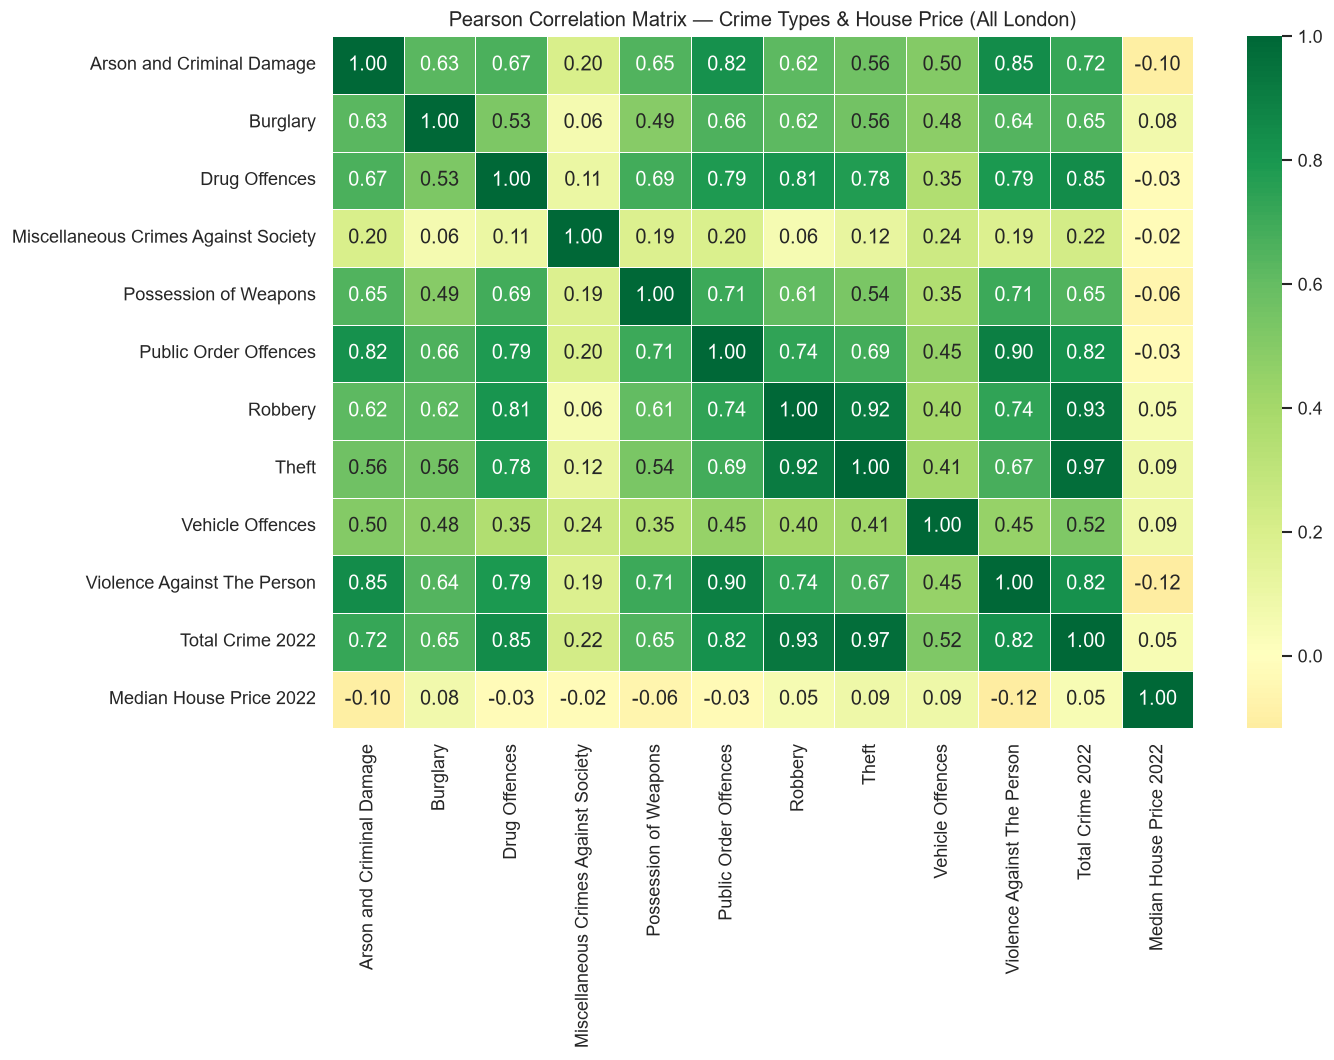

In [37]:
corr_cols = CRIME_COLS + ['Total Crime 2022', 'Median House Price 2022']
corr_matrix = merged_df[corr_cols].corr()

# Print correlation with house price
print('=== Pearson r with Median House Price 2022 (All London) ===')
price_corr = corr_matrix['Median House Price 2022'].drop('Median House Price 2022').sort_values()
for var, r_val in price_corr.items():
    _, p_val = pearsonr(merged_df[var], merged_df['Median House Price 2022'])
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f'  {var:<42} r = {r_val:+.4f}  p = {p_val:.4e}  {sig}')

# Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix — Crime Types & House Price (All London)', fontsize=12)
plt.tight_layout()
plt.show()

### 2. Simple Log-Log Regression: Each Crime Category vs House Price

For each crime type we run `log(Price) ~ log(1 + Crime)` and report β, R², and p-value across all four scenarios.

In [38]:
print('=== Simple Log-Log Regressions: β, R², p-value by Scenario ===')
print(f"{'Crime Type':<42} {'Scenario':<32} {'β':>8} {'R²':>8} {'p':>12}")
print('-' * 106)

for crime in CRIME_COLS:
    for name, df in scenarios.items():
        x = np.log1p(df[crime])
        y = np.log(df['Median House Price 2022'])
        X = sm.add_constant(x)
        res = sm.OLS(y, X).fit()
        beta = res.params[crime]
        r2   = res.rsquared
        pval = res.pvalues[crime]
        sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f"{crime:<42} {name:<32} {beta:>8.4f} {r2:>8.4f} {pval:>12.4e} {sig}")
    print()

=== Simple Log-Log Regressions: β, R², p-value by Scenario ===
Crime Type                                 Scenario                                β       R²            p
----------------------------------------------------------------------------------------------------------
Arson and Criminal Damage                  All London                        -0.1584   0.0655   4.9385e-72 ***
Arson and Criminal Damage                  Excl. Westminster                 -0.1793   0.0906   1.2732e-97 ***
Arson and Criminal Damage                  Excl. Westminster & K&C           -0.1827   0.1086  2.2465e-115 ***
Arson and Criminal Damage                  Trim Top 5% (Crime & Price)       -0.1627   0.0975   6.9766e-98 ***

Burglary                                   All London                         0.0214   0.0012   1.9232e-02 *
Burglary                                   Excl. Westminster                 -0.0084   0.0002   3.4835e-01 
Burglary                                   Excl. Westminster 

### 3. Multiple Log-Log OLS Regression: All 10 Crime Types

The full model: `log(Price) = β₀ + Σ βᵢ·log(1 + Crimeᵢ) + ε`  
Fit and summarised for each of the four scenarios.

In [39]:
for name, result in h2_results.items():  # h2_results already computed in Task 2
    print(f'\n{'='*60}')
    print(f'Multiple Log-Log OLS — {name}')
    print(f'{'='*60}')
    print(result.summary2().tables[0].to_string())
    print(result.summary2().tables[1][['Coef.', 'Std.Err.', 't', 'P>|t|', '[0.025', '0.975]']].to_string())


Multiple Log-Log OLS — All London
                     0                        1                    2          3
0               Model:                      OLS      Adj. R-squared:      0.282
1  Dependent Variable:  Median House Price 2022                 AIC:  3833.9337
2                Date:         2026-07-22 16:20                 BIC:  3905.0748
3    No. Observations:                     4757      Log-Likelihood:    -1906.0
4            Df Model:                       10         F-statistic:      188.0
5        Df Residuals:                     4746  Prob (F-statistic):       0.00
6           R-squared:                    0.284               Scale:    0.13078
                                          Coef.  Std.Err.           t          P>|t|     [0.025     0.975]
const                                 13.807070  0.040557  340.432706   0.000000e+00  13.727559  13.886582
Arson and Criminal Damage             -0.074464  0.012317   -6.045793   1.600660e-09  -0.098610  -0.050318
Burg

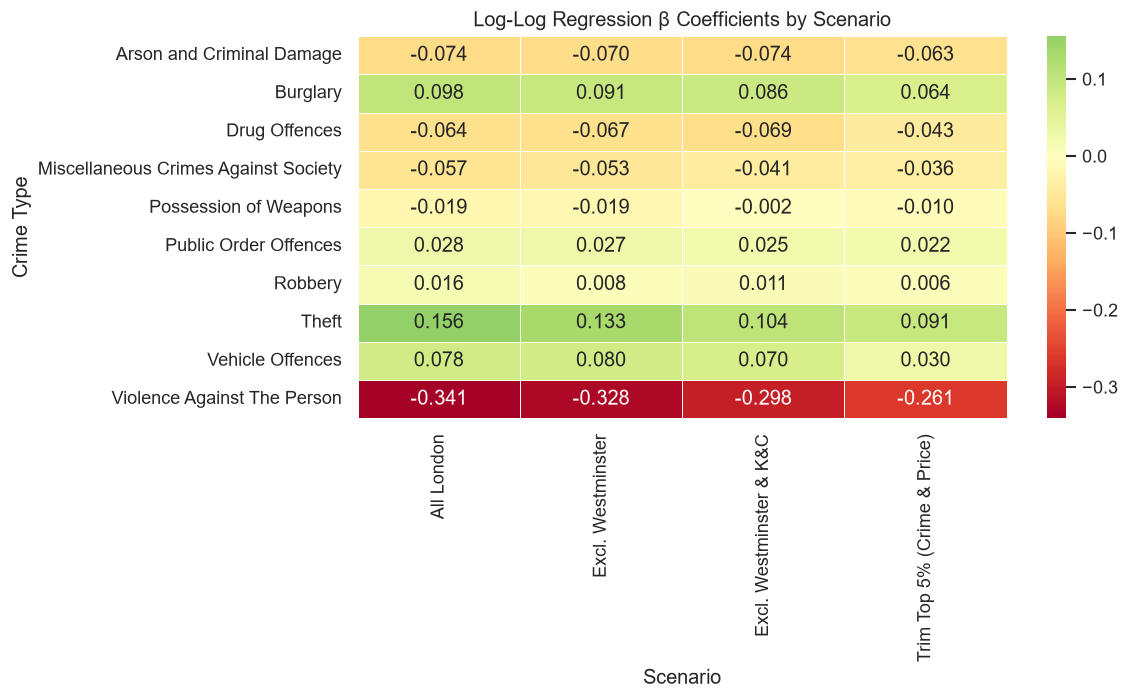

In [40]:
# Build a DataFrame: rows = crime types, cols = scenarios
coef_data = pd.DataFrame({
    name: result.params[CRIME_COLS] for name, result in h2_results.items()
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(coef_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Log-Log Regression β Coefficients by Scenario', fontsize=12)
ax.set_xlabel('Scenario')
ax.set_ylabel('Crime Type')
plt.tight_layout()
plt.show()

---
## Task 4: Analytical Insights and Recommendations

We summarise the key numerical findings across all scenarios and translate them into actionable recommendations for homebuyers, investors, and local authorities.

In [41]:
# Summary comparison table
print('=== Summary of Key Statistics Across Scenarios ===')
print(f"{'Scenario':<42} {'N':>5} {'r':>8} {'OLS Slope':>12} {'R² (multi)':>12} {'H1 p-value':>14}")
print('-' * 97)

for i, (name, df) in enumerate(scenarios.items()):
    r, _ = pearsonr(df['Total Crime 2022'], df['Median House Price 2022'])
    X = sm.add_constant(df['Total Crime 2022'])
    slope = sm.OLS(df['Median House Price 2022'], X).fit().params['Total Crime 2022']
    r2_multi = h2_results[name].rsquared
    p_h1 = h1_results[i]['p_one']
    print(f"{name:<42} {len(df):>5} {r:>8.4f} {slope:>12.2f} {r2_multi:>12.4f} {p_h1:>14.4e}")

=== Summary of Key Statistics Across Scenarios ===
Scenario                                       N        r    OLS Slope   R² (multi)     H1 p-value
-------------------------------------------------------------------------------------------------
All London                                  4757   0.0451        59.43       0.2838     4.3510e-12
Excl. Westminster                           4633  -0.0721      -146.23       0.2929     1.4567e-28
Excl. Westminster & K&C                     4535  -0.1041      -173.34       0.2861     1.4220e-55
Trim Top 5% (Crime & Price)                 4302  -0.2012      -517.90       0.2494     3.9608e-52


### Stakeholder Recommendations

#### Data-to-Insight Summary
| Scenario | r | Key Finding |
| :--- | :---: | :--- |
| All London | +0.045 | Positive confound: Westminster/K&C distort the global picture |
| Excl. Westminster | −0.072 | Removing tourist hubs reveals the true negative relationship |
| Excl. Westminster & K&C | −0.104 | Stronger negative signal in typical residential London |
| Trim Top 5% | −0.201 | Strongest evidence: crime strongly depresses prices in typical areas |

#### A. For Homebuyers and Investors
- **Distinguish crime types:** High theft/burglary areas are often wealthier, higher-amenity zones — not a deterrent. Focus on **violent crime** as the key signal: a 10% rise in violence is associated with a **~3.4% fall** in property values.
- **Target regeneration areas:** Look for neighbourhoods with falling violent crime; this is the strongest crime-related catalyst for value appreciation.

#### B. For Local Authorities and Planners
- **Focus resources on violent crime:** A 10% reduction in violent offences can recover up to 3.4% in local property values — a high return on public-safety investment.
- **Urban design to mitigate theft:** Secure-by-design principles (CCTV, lighting, secure parking) address theft clusters in wealthier areas without harming their economic productivity.
- **Interpret Westminster/K&C separately:** These boroughs operate under different dynamics (tourism, commerce) and should not be used as benchmarks for residential crime-price analysis.